In [173]:
import numpy as np
import matplotlib.pyplot as plt

### Generating noisy dataset

In [174]:
'''Generating noisy dataset based off of provided law'''
def dataset(f,D,n,eta):
    # randomly sample points in interval and evaluate
    rng = np.random.default_rng()
    s = rng.uniform(low=D[0], high=D[1], size=n)
    q = f(s)

    # add gaussian noise
    mag = np.sqrt(np.mean(q**2)) # RMS
    noise = np.random.normal(0.0,mag*eta,q.shape)
    q_noisy = q + noise

    return s,q_noisy

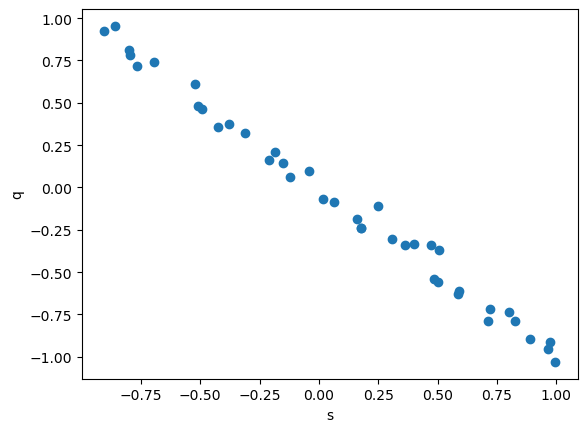

In [175]:
# linear (fourier) law
fluxlaw_lin = lambda s: -1*s
qs_lin = lambda s: 0*s-1
s_lin,q_lin = dataset(fluxlaw,[-1,1],40,0.1)
plt.scatter(s,q)
plt.xlabel("s")
plt.ylabel("q")
plt.show()

In [176]:
# nonlinear flux
# alpha = 0.25
# beta = 0.05
# fluxlaw = lambda s,T: -((1.0 + alpha*T**2) + beta*s**2) * s

### Fitting and evaluating basic models

In [177]:
s = s_lin.reshape(-1,1) 
q = q_lin

In [178]:
# A = np.zeros((4,2))
# A[1,:] = 1
# display(A)
# f = lambda x,y: x + y 
# display(f(*A.T))

# B = np.zeros((4,1))
# B[1] = 1
# display(B)
# g = lambda x: x+2 
# display(g(*B.T))

In [179]:
import numpy as np

def L2err(real,pred):
    return np.linalg.norm(real-pred) / np.linalg.norm(real)

'''Evaluate model accuracy (flux law and derivatives) on evenly spaced points.'''
def model_eval(model,scaler,I,n,q,q_s):
    # q predictions
    x = np.linspace(I[0],I[1],n).reshape(-1,1)
    x_scaled = scaler.transform(x) if scaler else x
    ypreds = model.predict(x_scaled)

    # obtain derivative approximations (centered)
    eta = 1e-5
    h_s = eta * np.maximum(1.0, np.abs(s))
    x_plus = x + h_s
    x_minus = x - h_s
    x_plus_scaled = scaler.transform(x_plus) if scaler else x_plus
    x_minus_scaled = scaler.transform(x_minus) if scaler else x_minus
    q_plus = model.predict(x_plus_scaled)
    q_minus = model.predict(x_minus_scaled) 
    qs_preds = (q_plus - q_minus) / (2.0 * h_s.reshape(-1))

    # evaluate accuracy
    err_q = L2err(np.asarray(q(x)).reshape(-1),ypreds)
    err_qs = L2err(q_s(x),qs_preds)
    print(f"flux relative L2 error: {err_q}")
    print(f"flux derivative relative L2 error: {err_qs}")

    return x,ypreds
    

##### Polynomial regression

training accuracy: 0.9942273247022445
flux relative L2 error: 0.024767750652693463
flux derivative relative L2 error: 0.263156228391934


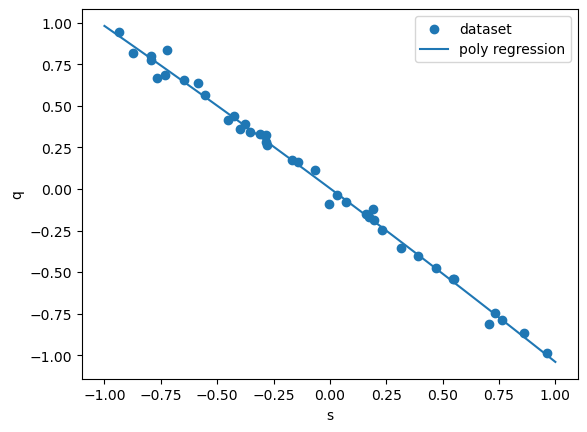

In [180]:
from sklearn.preprocessing import PolynomialFeatures 
from sklearn.linear_model import LinearRegression 

# fit polynomial regression (degree 2)
poly = PolynomialFeatures(degree=2)
s_quad = poly.fit_transform(s)
polyreg = LinearRegression()
polyreg.fit(s_quad,q)
print(f"training accuracy: {polyreg.score(s_quad,q)}")

x,poly_ypreds = model_eval(polyreg,poly,[-1,1],40,fluxlaw_lin,qs_lin)
plt.scatter(s,q,label="dataset")
plt.plot(x,poly_ypreds,label="poly regression")
plt.legend()
plt.xlabel("s")
plt.ylabel("q")
plt.show()

##### Kernel ridge

training accuracy: 0.9871561280344053
flux relative L2 error: 0.07382200623659241
flux derivative relative L2 error: 0.46689136231284134


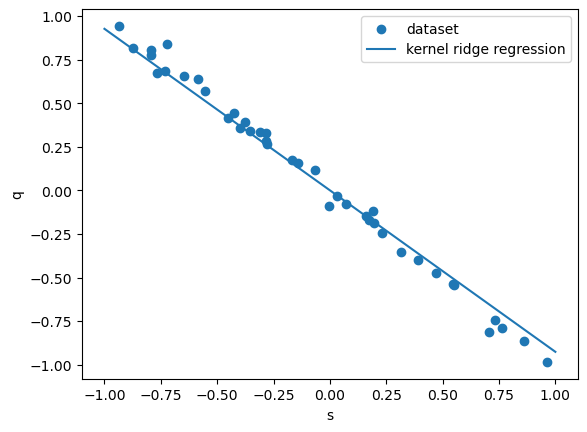

In [181]:
from sklearn.kernel_ridge import KernelRidge 

krr = KernelRidge()
krr.fit(s,q)
print(f"training accuracy: {krr.score(s,q)}")

x,krr_ypreds = model_eval(krr,None,[-1,1],40,fluxlaw_lin,qs_lin)
plt.scatter(s,q,label="dataset")
plt.plot(x,krr_ypreds,label="kernel ridge regression")
plt.legend()
plt.xlabel("s")
plt.ylabel("q")
plt.show()

##### Gaussian processes

training accuracy: 0.9949193568074969
flux relative L2 error: 0.06247713328529038
flux derivative relative L2 error: 5.678759903190054


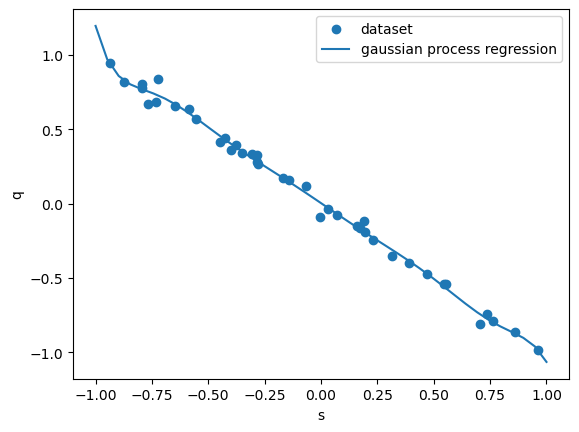

In [182]:
from sklearn.gaussian_process import GaussianProcessRegressor 

gpr = GaussianProcessRegressor()
gpr.fit(s,q)
print(f"training accuracy: {gpr.score(s,q)}")

x,gpr_ypreds = model_eval(gpr,None,[-1,1],40,fluxlaw_lin,qs_lin)
plt.scatter(s,q,label="dataset")
plt.plot(x,gpr_ypreds,label="gaussian process regression")
plt.legend()
plt.xlabel("s")
plt.ylabel("q")
plt.show()

##### Multilayer perceptron

training accuracy: 0.9886853574748671
flux relative L2 error: 0.11152351653039269
flux derivative relative L2 error: 2.168937631385163


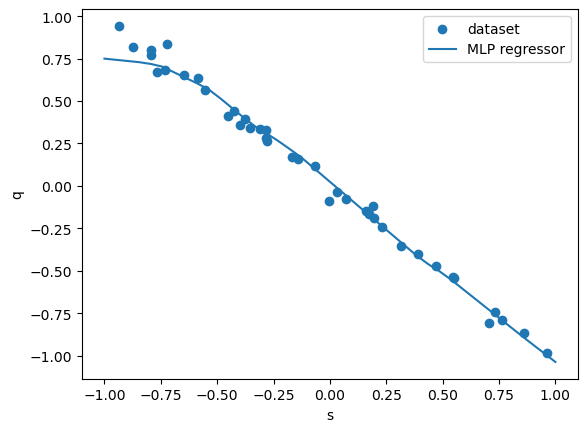

In [183]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

# train ANN
scaler = StandardScaler()
s_scaled = scaler.fit_transform(s.reshape(-1,1))
mlp = MLPRegressor(hidden_layer_sizes=(16,16),activation='relu',solver='adam',max_iter=200)
mlp.fit(s_scaled,q)
qpreds = mlp.predict(s_scaled)
print(f"training accuracy: {r2_score(q,qpreds)}")

# # test on evenly spaced points
# x = np.linspace(-1,1,40).reshape(-1,1)
# x_sc = scaler.transform(x)
# ypreds = mlp.predict(x_sc)
# plt.scatter(s,q)
# plt.plot(x,ypreds)
# plt.show()

x,mlp_ypreds = model_eval(mlp,scaler,[-1,1],40,fluxlaw_lin,qs_lin)
plt.scatter(s,q,label="dataset")
plt.plot(x,mlp_ypreds,label="MLP regressor")
plt.legend()
plt.xlabel("s")
plt.ylabel("q")
plt.show()

### Trained model as flux law

Checking impact on convergence time etc for Newton's method.

In [184]:
import FEM1D

def source(T, xg): # source
    return 1.0

def modelNM(model,transform):
    def fluxLaw(T_prime,T,xg):
        eta = 1e-5
        h_s = eta * np.maximum(1.0,np.abs(T_prime))
        x = np.array([T_prime-h_s,T_prime,T_prime+h_s]).reshape(-1,1)
        x_scaled = transform.transform(x) if transform else x
        y = model.predict(x_scaled)

        q = y[1]
        qs = (y[2]-y[0]) / (2.0*h_s)
        qT = 0

        return float(q), float(qs), qT

    U_exact = lambda x: 0.5*x*(1.0-x)
    return FEM1D.FEM_wrapper([0.0, 1.0], 20, fluxLaw, source, 0.0, 0.0, True,solution=U_exact) 


In [185]:
# baseline (analytic derivatives)
def baseFlux(T_prime, T, xg):
    q = -T_prime # we put k = 1 in q = -kT', the fourier law
    phi_s = -1.0
    phi_T = 0.0
    return q, phi_s, phi_T

U_exact = lambda x: 0.5*x*(1.0-x)
U_base,iter_base,evals_base,time_base,err_base = FEM1D.FEM_wrapper([0.0, 1.0], 20, baseFlux, source, 0.0, 0.0, True,solution=U_exact) 

Newton  0: ||R_eff||_2 = 2.179e-01
Newton  1: ||R_eff||_2 = 1.350e-15

FEM solution U:
[0.      0.02375 0.045   0.06375 0.08    0.09375 0.105   0.11375 0.12
 0.12375 0.125   0.12375 0.12    0.11375 0.105   0.09375 0.08    0.06375
 0.045   0.02375 0.     ]

Newton iterations: 2
Flux law evaluations: 249
Elapsed time: 0.0070720000003348105
Solution error: 2.6461161338376935e-15


In [186]:
U_poly,iter_poly,evals_poly,time_poly,err_poly = modelNM(polyreg,poly)

Newton  0: ||R_eff||_2 = 2.179e-01
Newton  1: ||R_eff||_2 = 3.961e-03
Newton  2: ||R_eff||_2 = 6.829e-07
Newton  3: ||R_eff||_2 = 1.359e-14

FEM solution U:
[0.         0.0232666  0.04413133 0.06258664 0.07862491 0.09223843
 0.10341943 0.11216008 0.11845243 0.1222885  0.1236602  0.12255937
 0.11897776 0.11290706 0.10433885 0.09326464 0.07967584 0.06356379
 0.04491972 0.02373477 0.        ]

Newton iterations: 4
Flux law evaluations: 581
Elapsed time: 0.18442779800170683
Solution error: 0.011452994157978296


In [187]:
U_krr,iter_krr,evals_krr,time_krr,err_krr = modelNM(krr,None)

Newton  0: ||R_eff||_2 = 2.179e-01
Newton  1: ||R_eff||_2 = 1.718e-15

FEM solution U:
[0.         0.02564302 0.04858677 0.06883126 0.08637649 0.10122244
 0.11336914 0.12281657 0.12956473 0.13361363 0.13496326 0.13361363
 0.12956473 0.12281657 0.11336914 0.10122244 0.08637649 0.06883126
 0.04858677 0.02564302 0.        ]

Newton iterations: 2
Flux law evaluations: 249
Elapsed time: 0.14473167399773956
Solution error: 0.07970606809240471


In [188]:
U_gpr,iter_gpr,evals_gpr,time_gpr,err_gpr = modelNM(gpr,None)

Newton  0: ||R_eff||_2 = 2.179e-01
Newton  1: ||R_eff||_2 = 1.143e-02
Newton  2: ||R_eff||_2 = 2.633e-03
Newton  3: ||R_eff||_2 = 6.966e-05
Newton  4: ||R_eff||_2 = 5.315e-06
Newton  5: ||R_eff||_2 = 3.664e-06
Newton  6: ||R_eff||_2 = 3.639e-06
Newton  7: ||R_eff||_2 = 3.193e-06
Newton  8: ||R_eff||_2 = 1.526e-06


RuntimeError: line search failed to minimize  residual

In [189]:
U_mlp,iter_mlp,evals_mlp,time_mlp,err_mlp = modelNM(mlp,scaler)

Newton  0: ||R_eff||_2 = 2.179e-01
Newton  1: ||R_eff||_2 = 2.414e-02
Newton  2: ||R_eff||_2 = 1.180e-02
Newton  3: ||R_eff||_2 = 5.468e-14

FEM solution U:
[0.         0.02191053 0.04122881 0.05833728 0.07323596 0.08592483
 0.09640391 0.10467317 0.11073264 0.11458231 0.11622217 0.11565223
 0.11287249 0.10788221 0.10057769 0.09059488 0.07787748 0.06211638
 0.04369607 0.02299061 0.        ]

Newton iterations: 4
Flux law evaluations: 581
Elapsed time: 0.2833308820008824
Solution error: 0.06694434816503034


### Results

| Model | Training accuracy | Flux err | Flux derivative err | Newton iterations | Flux law evals | Elapsed time | Solution err |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Baseline |  |  |  | 2 | 249 | 0.00707 | 2.65E-15 |
| Polynomial regression | 0.994 | 0.0247 | 0.263 | 4 | 581 | 0.184 | 0.01145 |
| Kernel ridge | 0.987 | 0.0738 | 0.467 | 2 | 249 | 0.1447 | 0.07971 |
| Gaussian process | 0.995 | 0.0625 | 5.28 |  |  |  |  |
| MLP | 0.989 | 0.111 | 2.169 | 4 | 581 | 0.2833 | 0.0669 |